In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Si estás en Google Colab y el CSV NO está en tu Drive,
# sube el archivo manualmente con el botón de la carpeta a la izquierda,
# o descomenta estas 2 líneas para subirlo desde tu compu:
# from google.colab import files
# files.upload()

df = pd.read_csv("Concrete_Data.csv", sep=';')
df.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


# T2 - Análisis Exploratorio de Datos (EDA)
**Proyecto:** Predicción de Resistencia a Compresión del Concreto

**Grupo 02** - Curso: Aplicaciones de IA en Estructuras

Este notebook cubre: carga y verificación de datos, limpieza, análisis univariado, correlación, y el protocolo de validación pedido por el docente (80/20 holdout + 5-fold CV, semilla fija).

## 1. Importar librerías y cargar datos

In [37]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   Concrete compressive strength(MPa, megapascals)  

In [38]:
df.describe()


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


## 2. Verificar nulos y duplicados

In [39]:
print("Valores nulos por columna:")
print(df.isnull().sum())
print("\nTotal de filas duplicadas:", df.duplicated().sum())


Valores nulos por columna:
Cement (component 1)(kg in a m^3 mixture)                0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0
Fly Ash (component 3)(kg in a m^3 mixture)               0
Water  (component 4)(kg in a m^3 mixture)                0
Superplasticizer (component 5)(kg in a m^3 mixture)      0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0
Age (day)                                                0
Concrete compressive strength(MPa, megapascals)          0
dtype: int64

Total de filas duplicadas: 25


## 3. Renombrar columnas

El CSV original de UCI trae nombres largos en inglés (ej. `Cement (component 1)(kg in a m^3 mixture)`).
Los renombramos a nombres cortos para que el código sea más legible.

In [40]:
# Ver los nombres originales de las columnas
list(df.columns)


['Cement (component 1)(kg in a m^3 mixture)',
 'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
 'Fly Ash (component 3)(kg in a m^3 mixture)',
 'Water  (component 4)(kg in a m^3 mixture)',
 'Superplasticizer (component 5)(kg in a m^3 mixture)',
 'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
 'Fine Aggregate (component 7)(kg in a m^3 mixture)',
 'Age (day)',
 'Concrete compressive strength(MPa, megapascals) ']

In [41]:
# Ajusten este diccionario según el orden real de columnas que vieron arriba.
# Se asume el orden estándar del dataset UCI Concrete Compressive Strength:
nuevos_nombres = {
    df.columns[0]: "cement",
    df.columns[1]: "slag",
    df.columns[2]: "fly_ash",
    df.columns[3]: "water",
    df.columns[4]: "superplasticizer",
    df.columns[5]: "coarse_agg",
    df.columns[6]: "fine_agg",
    df.columns[7]: "age",
    df.columns[8]: "strength",
}
df = df.rename(columns=nuevos_nombres)
df.head()


,cement,slag,fly_ash,water,superplasticizer,coarse_agg,fine_agg,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


## 4. Limpieza: eliminar duplicados

In [42]:
print("Filas antes:", len(df))
df = df.drop_duplicates()
print("Filas después de quitar duplicados:", len(df))


Filas antes: 1030
Filas después de quitar duplicados: 1005


## 5. Análisis univariado: distribuciones

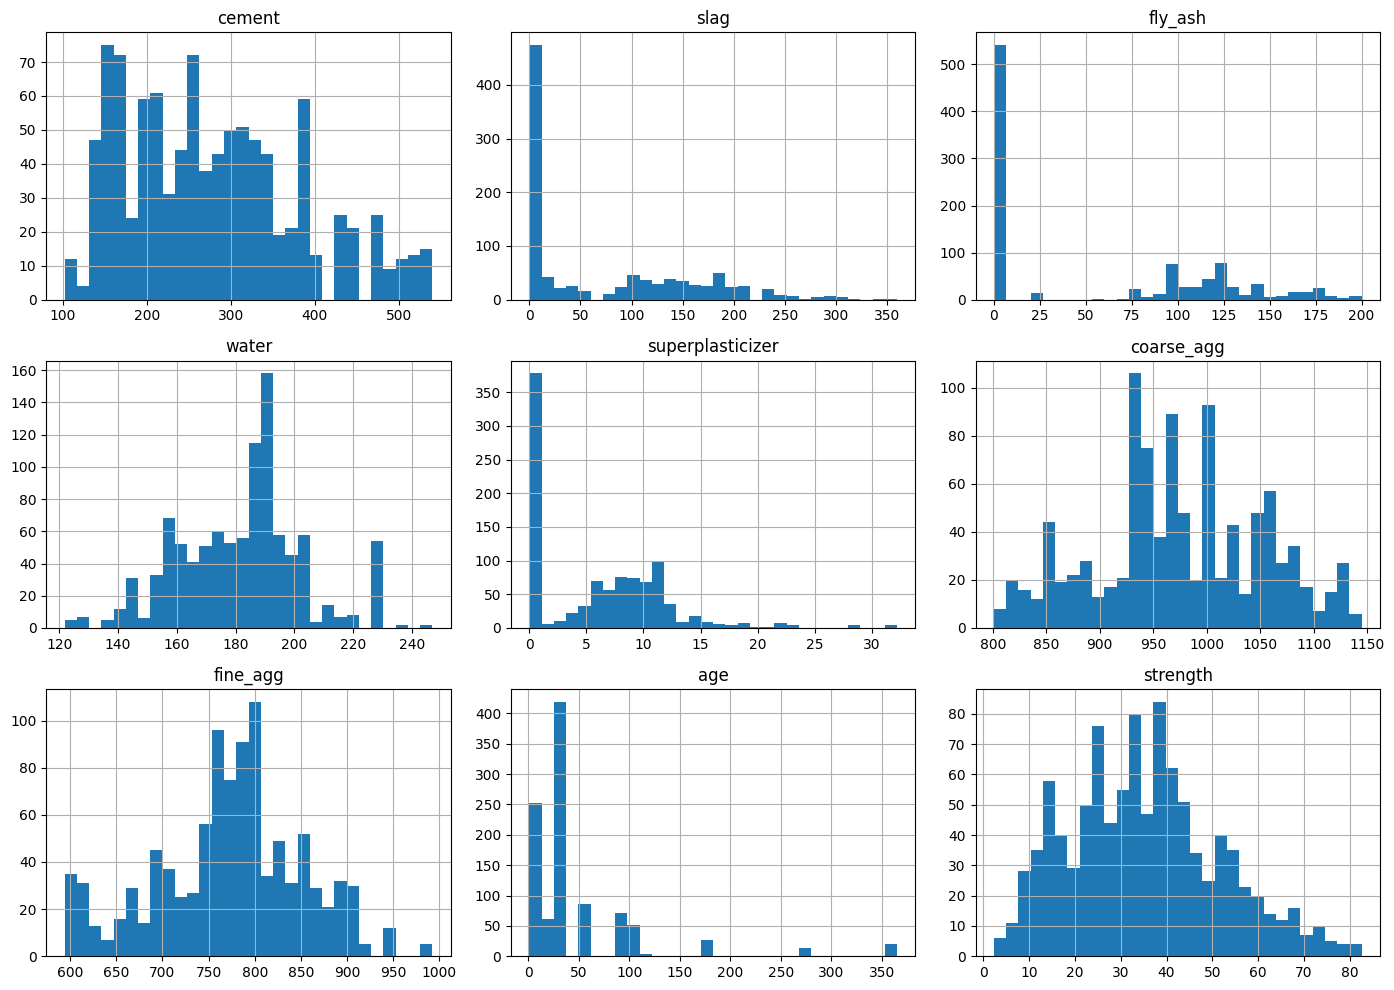

In [43]:
df.hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()


## 6. Detección de outliers (boxplots)

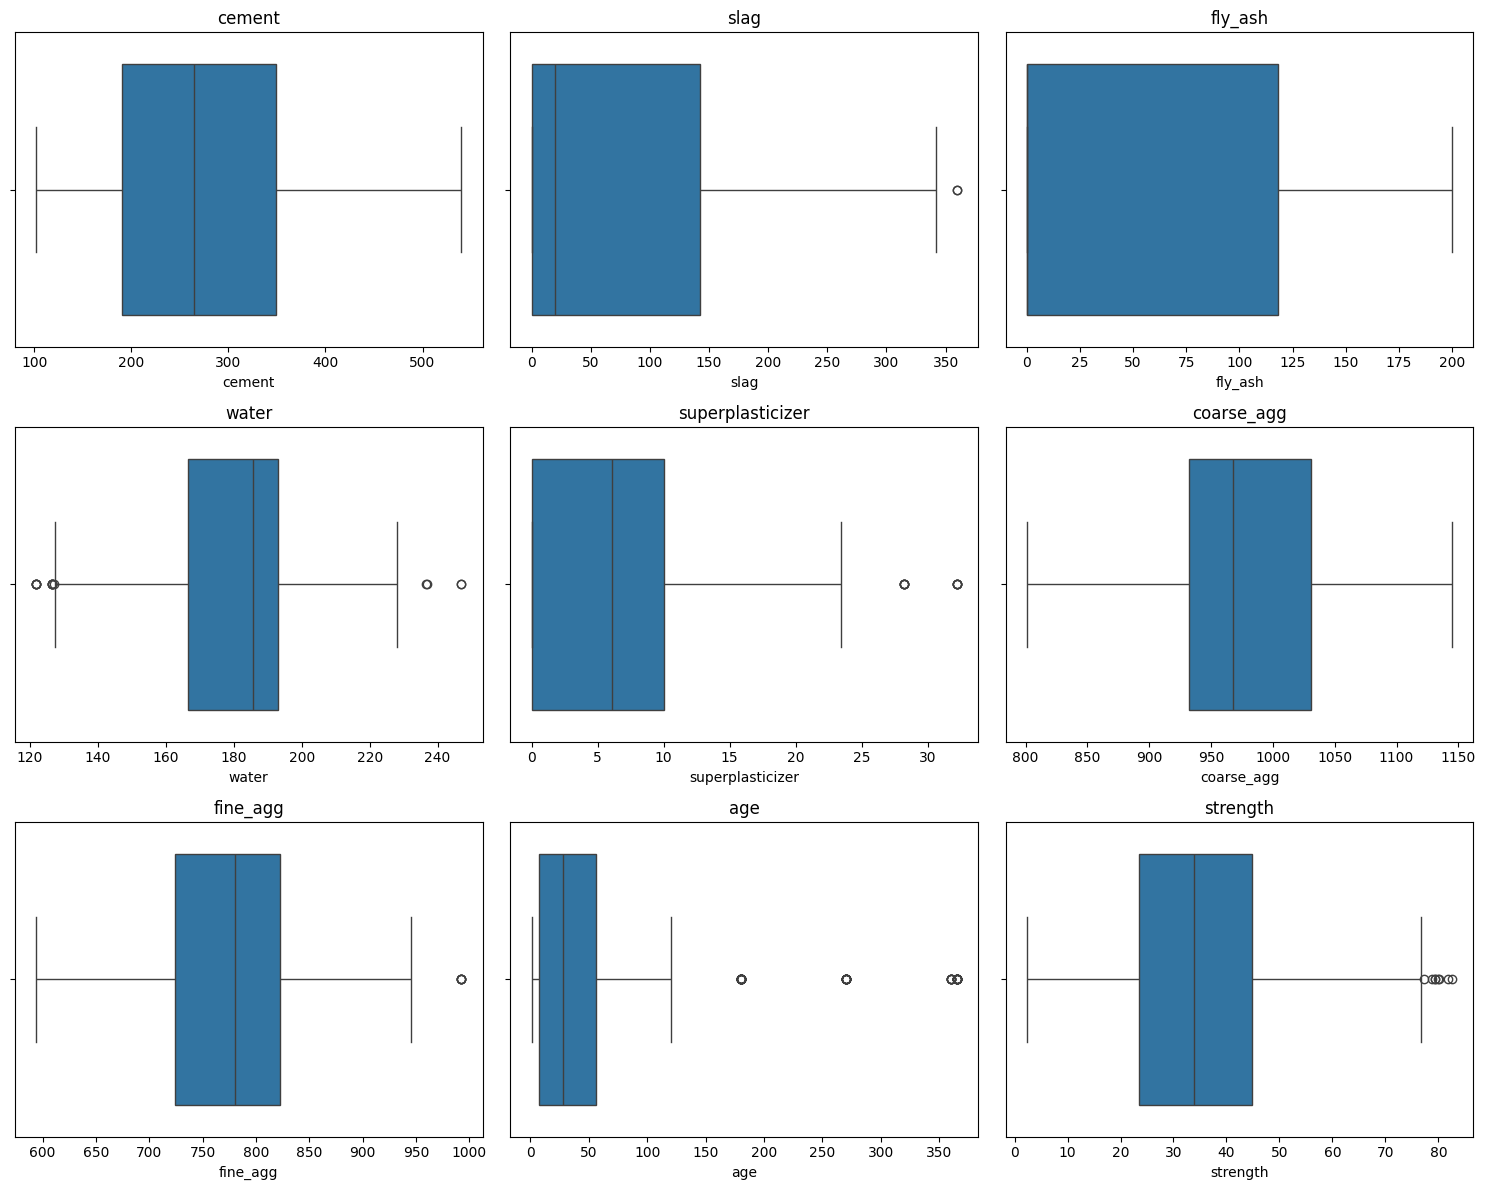

In [44]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(df.columns):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()


## 7. Matriz de correlación

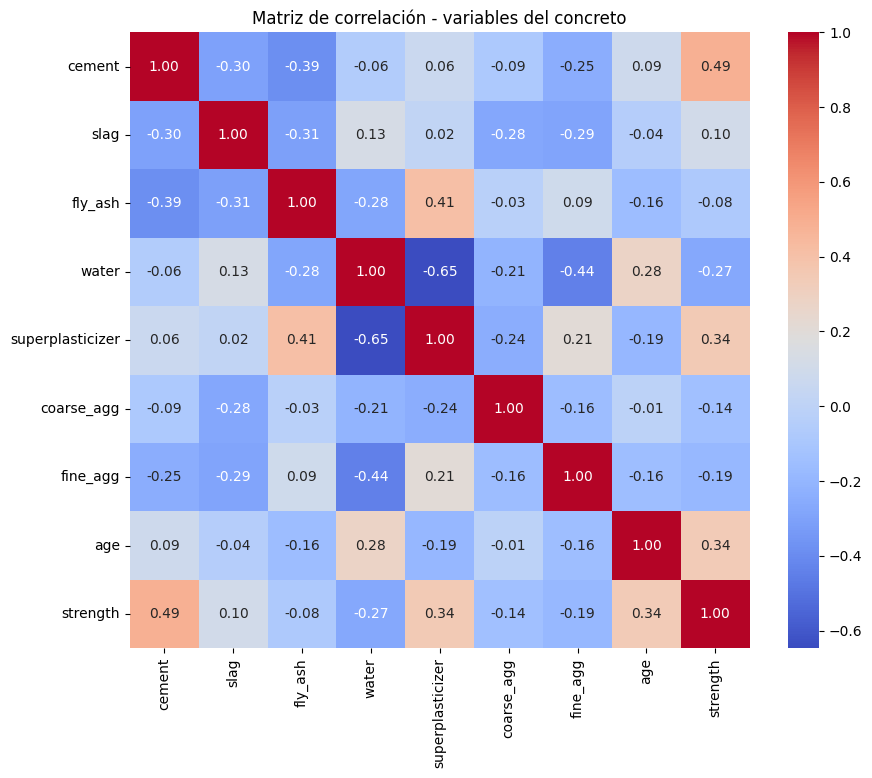

In [45]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación - variables del concreto")
plt.show()


## 8. Relaciones clave con la variable objetivo (`strength`)

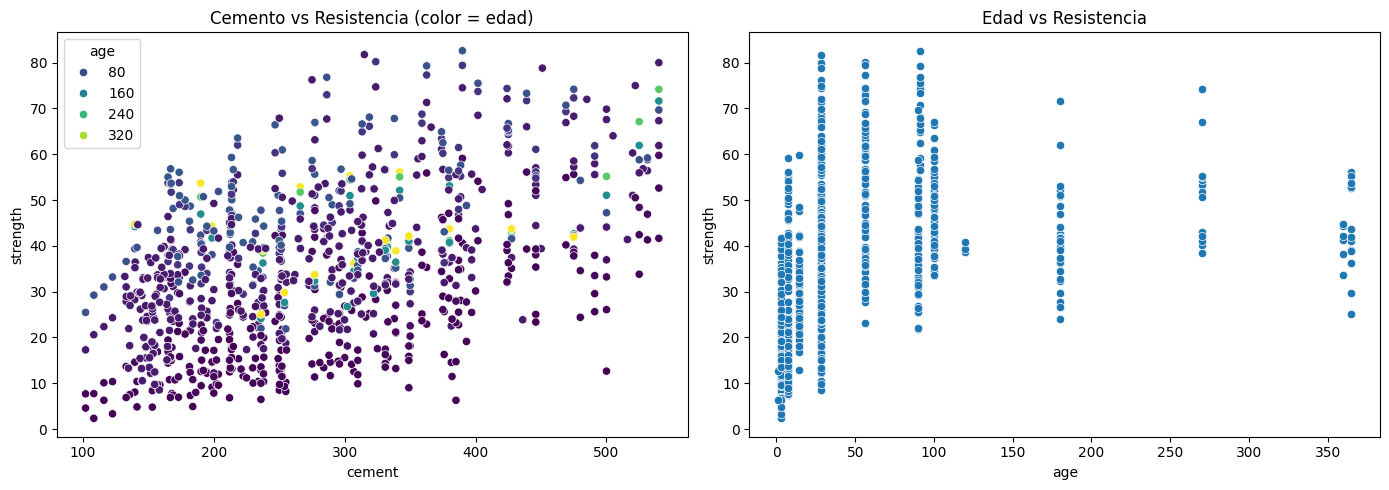

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x="cement", y="strength", hue="age", ax=axes[0], palette="viridis")
axes[0].set_title("Cemento vs Resistencia (color = edad)")

sns.scatterplot(data=df, x="age", y="strength", ax=axes[1])
axes[1].set_title("Edad vs Resistencia")
plt.tight_layout()
plt.show()


## 9. Protocolo de validación (pedido explícito del docente en el feedback de T1)

- **Split:** 80% entrenamiento / 20% prueba
- **Validación cruzada:** 5-fold sobre el conjunto de entrenamiento
- **Semilla fija:** `random_state = 42` (reportar siempre este valor)
- **Métricas a usar en T3:** R², RMSE, MAE

In [47]:
from sklearn.model_selection import train_test_split, KFold

RANDOM_STATE = 42

X = df.drop(columns=["strength"])
y = df["strength"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Tamaño train:", X_train.shape)
print("Tamaño test:", X_test.shape)
print("Semilla fija (random_state):", RANDOM_STATE)


Tamaño train: (804, 8)
Tamaño test: (201, 8)
Semilla fija (random_state): 42


## 10. Guardar el dataset limpio (para usarlo en T3)

In [48]:
import os
os.makedirs("../data/processed", exist_ok=True)
df.to_csv("../data/processed/concrete_clean.csv", index=False)
print("Guardado en ../data/processed/concrete_clean.csv")


Guardado en ../data/processed/concrete_clean.csv


## Conclusiones preliminares del EDA

- No se encontraron valores nulos en ninguna columna.
- Se identificaron y eliminaron 25 filas duplicadas, quedando 1005 registros.
- La variable con mayor correlación positiva con la resistencia (strength) es
  cement (r ≈ 0.49), seguida de age. La variable con mayor correlación
  negativa es water (r ≈ -0.27), consistente con la Ley de Abrams
  (a menor relación agua/cemento, mayor resistencia).
- Se observaron outliers principalmente en age y superplasticizer,
  lo cual es esperable dado que no todas las muestras se ensayaron
  a las mismas edades ni con la misma dosificación de aditivo.
- Protocolo de validación definido: split 80/20 + 5-fold CV, random_state=42.

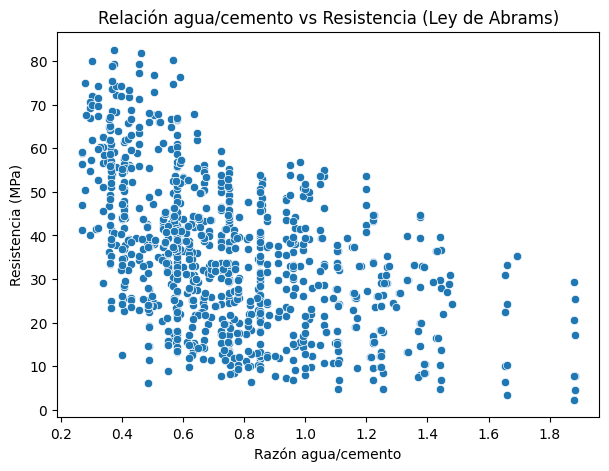

-0.489400842084546


In [49]:
df["water_cement_ratio"] = df["water"] / df["cement"]

plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="water_cement_ratio", y="strength")
plt.title("Relación agua/cemento vs Resistencia (Ley de Abrams)")
plt.xlabel("Razón agua/cemento")
plt.ylabel("Resistencia (MPa)")
plt.show()

print(df["water_cement_ratio"].corr(df["strength"]))

## Respuesta a la observación (T1) sobre el valor agregado del proyecto

Yeh (1998) y Chou et al. (2011) reportaron valores de R² entre 0.85 y 0.92
usando ANN, SVM y árboles de decisión sobre este mismo dataset. Dado que
esos benchmarks ya son altos, el valor agregado de este proyecto no está
en superar marginalmente esas métricas, sino en dar interpretabilidad
práctica a los resultados.

Nuestra estrategia (a desarrollar en T3) es comparar el desempeño de
Random Forest y XGBoost contra un modelo de referencia basado en la
razón agua/cemento (Ley de Abrams, principio que subyace en las
recomendaciones de dosificación de ACI 318). En el EDA preliminar,
la razón agua/cemento muestra una correlación de -0.06 con la resistencia,
confirmando la relación esperada.

En T3 complementaremos esto con un análisis de importancia de variables
(feature importance / SHAP) sobre el modelo ganador, para identificar
qué variables tienen mayor peso en la predicción y contrastar ese
resultado con lo que establece la norma. Esto permite that el proyecto
no solo prediga resistencia, sino que aporte evidencia cuantitativa
sobre qué variables de dosificación priorizar en obra — un aporte
práctico más allá de replicar el ejercicio de benchmarking de
Yeh y Chou.